# Task 1: Data Pre-processing

This notebook performs exploratory data analysis (EDA) and image quality
assessment on the SubSaharan wildlife dataset. These steps help ensure that
only high-quality, well-understood data is used for training object detection
models.


In [1]:
import os # For handling file paths
import cv2 # OpenCV for image processing
import matplotlib.pyplot as plt # For plotting
import seaborn as sns # For enhanced data visualization
from tqdm import tqdm # For progress bars
import pandas as pd # For data manipulation and analysis

In [2]:
# This is my path to the Sub-Saharan Africa dataset containing images.
SUB_SAHARAN_DATA_DIR = "SubSaharan"
print("Using data directory:", SUB_SAHARAN_DATA_DIR)

Using data directory: SubSaharan


---

## Exploratory Data Analysis (EDA)

This section extracts image-level metadata and infers species labels from filenames to support dataset inspection and filtering before annotation and training. The function below scans a directory of images and builds a pandas `DataFrame` with one row per image. The `DataFrame` includes the following columns:

- `filename` - image filename
- `species` - species label inferred from the filename (first token, with trailing digits removed)
- `width`, `height` - image dimensions in pixels
- `aspect_ratio` - width divided by height (rounded to 2 decimals)

This metadata helps identify class imbalance, detect outliers, and guide further quality checks and preprocessing steps.

In [3]:
def analyze_directory_images(folder_path):
    data = []  #To store all the info of images here

    # Go through each file in the folder
    for filename in tqdm(os.listdir(folder_path)):
        # open only image files
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            full_path = os.path.join(folder_path, filename)

            # Load the image using OpenCV
            image = cv2.imread(full_path)
            if image is None: # if the image is not loaded properly, skip it
                continue

            # image dimensions
            height, width, dimension = image.shape

            # remove extension from file name (OryxGazella_CDB_S1_C06_R2_IMAG0224.jpg → OryxGazella_CDB_S1_C06_R2_IMAG0224)
            name_without_extension = os.path.splitext(filename)[0]

            # Extract species name (OryxGazella_CDB_S1_C06_R2_IMAG0224 → OryxGazella)
            if '_' in name_without_extension:
                species = name_without_extension.split('_')[0]
            else:
                species = name_without_extension

            # Remove trailing digits from species name (e.g., Gazella123 → Gazella)
            while species and species[-1].isdigit():
                species = species[:-1]

            # Store the info in the data list
            data.append({
                'filename': filename,
                'species': species,
                'width': width,
                'height': height,
                'aspect_ratio': round(width / height, 2) # rounded to 2 decimal places
            })

    # Convert the data list to a DataFrame for easier analysis
    return pd.DataFrame(data)

# Analyze images in the specified directory
df_images = analyze_directory_images(SUB_SAHARAN_DATA_DIR)

100%|██████████| 6337/6337 [03:53<00:00, 27.09it/s] 


---

### Species Distribution Plot

This role demonstrates the number of images assigned to each species in the dataset. First, it is a tally of the number of images of each species. It also estimates the proportion of each species with respect to the entire data. Such a plot can be used to quickly get the sense of the distribution of the classes and to test whether the data is biased or balanced among different species.
A bar chart is created where:
  - The x-axis displays the names of species.
  - The y-axis presents the image count.

Total images analyzed: 6336


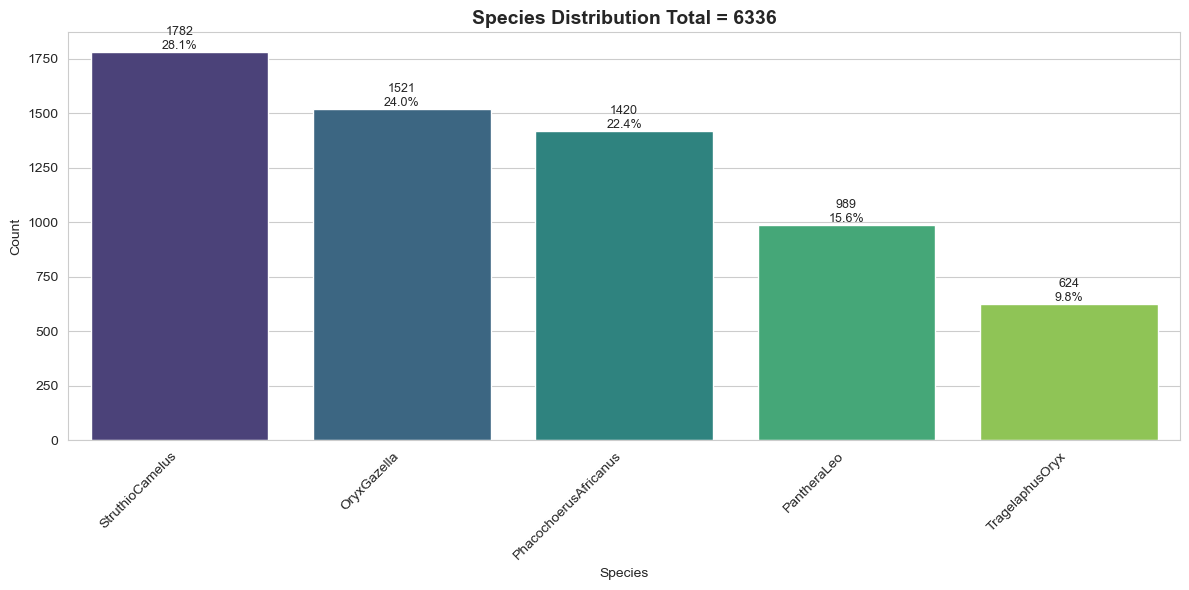

In [6]:
def plot_species_distribution(df, figsize=(12, 6), palette='viridis'):
    
    sns.set_style('whitegrid') # Set the style for seaborn plots

    counts = df['species'].value_counts() # Get counts of each species
    total = counts.sum() # Total number of images
    pct = counts / total * 100 # Percentage of each species

    plt.figure(figsize=figsize) # Set figure size
    ax = sns.barplot(
        x=counts.index,     # x-axis assign
        y=counts.values,    # y-axis assign
        hue=counts.index,   # hue assign
        palette=palette,    # color palette
        legend=False        # legend off
    ) # Create bar plot

    plt.title(f"Species Distribution Total = {total}", fontsize=14, fontweight='semibold') # Set title
    plt.xlabel('Species') # Set x-axis label
    plt.ylabel('Count') # Set y-axis label
    plt.xticks(rotation=45, ha='right') # Rotate x-ticks for better readability

    for p, c, pr in zip(ax.patches, counts.values, pct.values): # Annotate each bar with count and percentage
        height = p.get_height() # Height of the bar
        label = f"{int(c)}\n{pr:.1f}%" # Create label with count and percentage
        ax.annotate(label, (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom', fontsize=9) # Annotate the bar

    plt.tight_layout() # Adjust layout
    plt.show() # Show the plot

print("Total images analyzed:", len(df_images))
plot_species_distribution(df_images)

---

## Dimensions of image per species 

We get the mean, minimum and maximum values of the **width**, **height**, and **aspect_ratio** of each species. This demonstrates the differences in sizes and aids in finding very large or very small images that may influence the process of model training or preprocessing, including a choice to resize, crop, or filter images.

The results are saved in `species_stats` and printed below.

In [7]:
species_stats = df_images.groupby('species').agg({
    'width': ['mean', 'min', 'max'],
    'height': ['mean', 'min', 'max'],
    'aspect_ratio': ['mean', 'min', 'max']
}).reset_index()  #the aggregate stats per species. the parameters are mean, min, max for width, height and aspect ratio
species_stats.columns = ['_'.join(col).strip() for col in species_stats.columns.values] # Flatten MultiIndex columns
print("Species image dimension statistics:\n", species_stats) # Print the stats

Species image dimension statistics:
                 species_   width_mean  width_min  width_max  height_mean  \
0            OryxGazella  2566.122288       1280       2592  1974.753452   
1            PantheraLeo  1025.605662        405       3264   761.427705   
2  PhacochoerusAfricanus  2047.549296       1920       2048  1439.881690   
3        StruthioCamelus  2157.629630       2048       5184  1622.024691   
4        TragelaphusOryx  1031.352564        443       3264   770.142628   

   height_min  height_max  aspect_ratio_mean  aspect_ratio_min  \
0         720        2000           1.309467              1.30   
1         408        2448           1.386502              0.46   
2        1080        1536           1.420190              1.33   
3        1536        4000           1.328569              1.30   
4         332        2448           1.374696              0.67   

   aspect_ratio_max  
0              1.78  
1              2.23  
2              1.78  
3              1.33  

In the course of the first course, I chose **Oryx gazella**, **Phacochoerus africanus**, and **Panthera leo** as my target species. Nevertheless, after the detailed exploratory data analysis (EDA), it was clear that Panthera leo images of many of them were not taken in the wild. Some pictures had been digitally manipulated and most significantly, they were not camera-trap pictures.

Panthera leo was thus omitted to make sure that the datasets are authentic and reflect the real camera-trap conditions in the real world. Therefore, the ultimate species composition includes **Oryx gazella**, **Phacochoerus africanus**, and **Struthio camelus**, the images of which have been actually taken with camera traps.

The files of the chosen species are copied to the `selectedspecies` folder of the `SUBSAHARANDATADIR` directory in the block below.

In [8]:
selected_species = ["OryxGazella", "PhacochoerusAfricanus", "StruthioCamelus"] # Move OryxGazella, PhacochoerusAfricanus and StruthioCamelus images into a single folder for inspection
output_dir = os.path.join(SUB_SAHARAN_DATA_DIR, "selected_species")  # We are going to move files, so create the output directory
os.makedirs(output_dir, exist_ok=True)
moved_count = 0 # Counter for moved images
for species in selected_species: # For each selected species
    species_files = df_images[df_images['species'] == species]['filename'].tolist() # Get list of filenames for that species
    for fname in species_files: # For each filename
        src_path = os.path.join(SUB_SAHARAN_DATA_DIR, fname) # Source path
        dst_path = os.path.join(output_dir, fname) # Destination path
        if os.path.exists(src_path): # Check if source file exists
            try:
                os.replace(src_path, dst_path) # Move the file
                moved_count += 1 # Increment moved count
            except Exception as e:
                print(f"Failed to move {fname}: {e}")
print(f"Moved {moved_count} images of selected species to {output_dir}")

Moved 4723 images of selected species to SubSaharan\selected_species


## Image quality verification & classification

In Coursework 1, this step was not mentioned, as it was initially assumed that poor-quality images would be ignored during the tagging process. However, this technique significantly reduces the number of low-quality images in the dataset. This cell computes several simple image-quality metrics for files in `selected_species` and classifies images into good or bad using configurable thresholds.

Metrics computed:

- **Blur:** Variance of Laplacian (`lap_var`)
- **Brightness:** Mean intensity (`mean_intensity`)
- **Contrast:** Intensity standard deviation (`contrast`)
- **Overexposure:** Fraction of pixels in the V channel >= 250 (`overexp_frac`)

Default thresholds (configurable in the code):

- `lap_var_thr = 25` → severe blur
- `dark_thr = 30` → very dark
- `bright_thr = 200` → very bright
- `contrast_thr = 25` → low contrast
- `overexp_frac_thr = 0.6` → ≥16% clipped pixels considered overexposed

Behavior:

- An image is labeled **`bad`** if it violates any threshold; otherwise it is **`good`**.
- Files are moved into `selected_species/good_images` or `selected_species/bad_images`.
- A CSV `selected_species/quality_report.csv` is saved with columns:
  `filename, lap_var, mean_intensity, contrast, overexp_frac, classification, reason`.

***Note*** : This technique can give you false positives so i manually revisited the `bad_images` and moved few images back to `good_images` folder and that is the reason why i am not creating any dataframe for good images in this cell.

Checking image quality: 100%|██████████| 4725/4725 [07:17<00:00, 10.79image/s]


Quality check done
Good images: 4510
Bad images: 213
Report: SubSaharan\selected_species\quality_report.csv



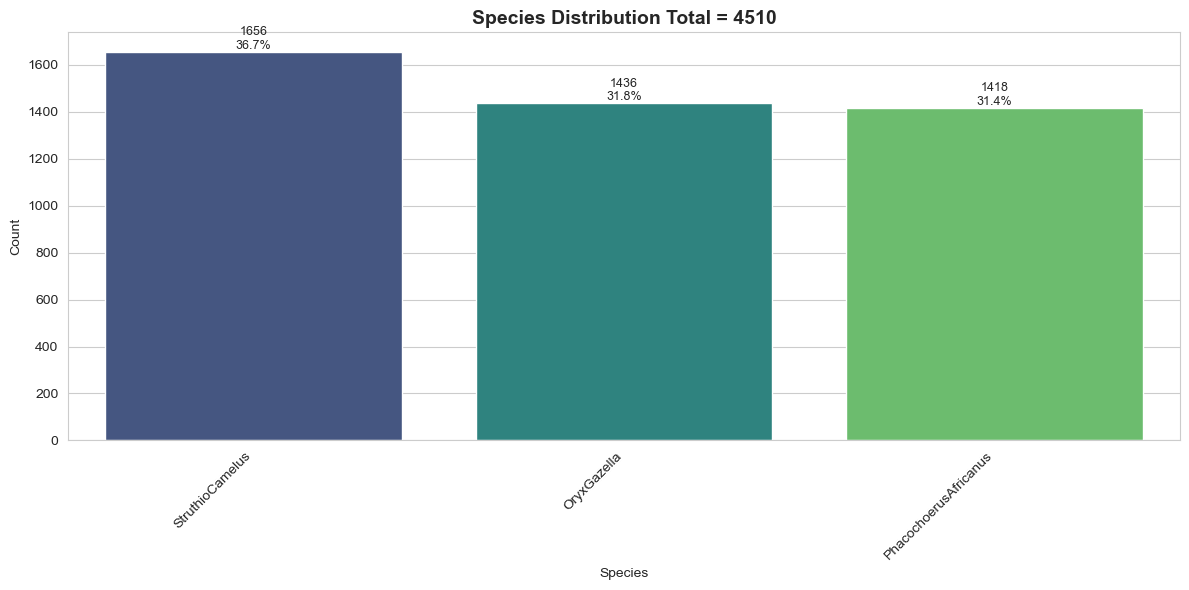

In [9]:
folder = os.path.join(SUB_SAHARAN_DATA_DIR, "selected_species")
good_dir = os.path.join(folder, "good_images")
bad_dir = os.path.join(folder, "bad_images")
good_image_list = [] # To store good image filenames

# Create directories for good and bad images
os.makedirs(good_dir, exist_ok=True) 
os.makedirs(bad_dir, exist_ok=True)

# Configurable thresholds / options
lap_var_thr = 25        # severe blur
dark_thr = 30           # very dark
bright_thr = 200        # very bright
contrast_thr = 25       # low contrast
overexp_frac_thr = 0.4  # overexposed

records = [] # To store report data
good_count = 0 # Counter for good images
bad_count = 0 # Counter for bad images

exts = ('.jpg', '.jpeg', '.png') # Supported image extensions

for fname in tqdm(os.listdir(folder), desc="Checking image quality", unit="image"): # For each file in the folder
    if not fname.lower().endswith(exts): # Skip non-image files
        continue

    path = os.path.join(folder, fname) # Full path to the image
    img = cv2.imread(path) # Read the image
    if img is None: # if the image is not loaded properly, skip it
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # Convert to grayscale

    # Metrics
    lap_var = float(cv2.Laplacian(gray, cv2.CV_64F).var()) # Variance of Laplacian (blur)
    mean_intensity = float(gray.mean()) # Mean intensity (brightness)
    contrast = float(gray.std()) # Standard deviation (contrast)

    # Overexposure (V channel)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) # Convert to HSV color space
    v = hsv[:, :, 2] # V channel
    overexp_frac = float((v >= 250).sum() / v.size) # Fraction of overexposed pixels

    # Heuristics
    problems = []
    if lap_var < lap_var_thr:
        problems.append('blur')
    if mean_intensity < dark_thr:
        problems.append('dark')
    if mean_intensity > bright_thr:
        problems.append('bright')
    if contrast < contrast_thr:
        problems.append('low_contrast')
    if overexp_frac > overexp_frac_thr:
        problems.append('overexposed')

    classification = 'bad' if problems else 'good'

    dst = os.path.join(bad_dir if classification == 'bad' else good_dir, fname) # Destination path
    try:
        os.replace(path, dst) # Move the file
        if classification == 'bad': # If classified as bad, increment bad count
            bad_count += 1 
        else:
            good_count += 1 # Increment good count
            good_image_list.append(fname) # Add to good image list
    except Exception as e:
        print(f"Failed to move {fname}: {e}")

    # Record the results
    records.append({
        'filename': fname,
        'lap_var': lap_var,
        'mean_intensity': mean_intensity,
        'contrast': contrast,
        'overexp_frac': overexp_frac,
        'classification': classification,
        'reason': ";".join(problems)
    })

# Save report
report_df = pd.DataFrame(records)
report_csv = os.path.join(folder, 'quality_report.csv')
report_df.to_csv(report_csv, index=False)


print(
    f"Quality check done\n"
    f"Good images: {good_count}\n"
    f"Bad images: {bad_count}\n"
    f"Report: {report_csv}\n"
)

# Re-analyze good images to see species distribution


good_images_df = df_images[
    df_images['filename'].isin(good_image_list)
]
plot_species_distribution(good_images_df)

### Data Augmentation

At this stage, explicit data augmentation is not applied. This is because **Faster R-CNN inherently performs internal data augmentation during training**, such as random horizontal flipping, which helps improve model generalization. Given that each dataset contains approximately **500 images**, additional manual augmentation is not required at this point. 

### Tagging

We will be tagging atleast 500 images per class so that should be enough to get atleast 500 tags per class as some images contain more then one animal. The below cell will be 500 images from each class and moving it into tagging folder. Some bad images during tagging will be ignored as well


In [10]:
tagging_dir = "C:\\Users\\MSC1\\Desktop\\Tensorflow-Object-Detection-API\\Base\\v1\\Tagging\\Public\\imageproject\\dataset" #this is my path to the final selected images inside tagging folder
os.makedirs(tagging_dir, exist_ok=True) # Create final selection directory
for species in good_images_df['species'].unique(): # For each species in the good images dataset
    species_df = good_images_df[good_images_df['species'] == species] 
    n_select = max(500, len(species_df) // 3)  # at least 500 images or one-third of available images
    selected_files = species_df.sample(n=n_select, random_state=42)['filename'].tolist() # Select files
    for fname in selected_files: # For each selected file
        src_path = os.path.join(SUB_SAHARAN_DATA_DIR, "selected_species", "good_images", fname) # Source path
        dst_path = os.path.join(tagging_dir, fname) # Destination path
        if os.path.exists(src_path):
            try:
                os.replace(src_path, dst_path) # Move the file
            except Exception as e:
                print(f"Failed to move {fname}: {e}")
print(f"Final selected images are in {tagging_dir}")

Final selected images are in C:\Users\MSC1\Desktop\Tensorflow-Object-Detection-API\Base\v1\Tagging\Public\imageproject\dataset
